In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
import pandas as pd

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
amzn_data = pd.read_csv('AMZN.csv')
goog_data = pd.read_csv('GOOG.csv')
msft_data = pd.read_csv('MSFT.csv')

# Display the first few rows to verify the data
print(aapl_data.head())
print(amzn_data.head())
print(goog_data.head())
print(msft_data.head())

       Date       Open       High        Low      Close  Adj Close     Volume
0  2014/1/2  19.845715  19.893929  19.715000  19.754642  17.253254  234684800
1  2014/1/3  19.745001  19.775000  19.301071  19.320715  16.874277  392467600
2  2014/1/6  19.194643  19.528570  19.057142  19.426071  16.966293  412610800
3  2014/1/7  19.440001  19.498571  19.211430  19.287144  16.844955  317209200
4  2014/1/8  19.243214  19.484285  19.238930  19.409286  16.951632  258529600
         Date       Open     High        Low      Close  Adj Close    Volume
0  2014-01-02  19.940001  19.9680  19.701000  19.898500  19.898500  42756000
1  2014-01-03  19.914499  20.1355  19.811001  19.822001  19.822001  44204000
2  2014-01-06  19.792500  19.8500  19.421000  19.681499  19.681499  63412000
3  2014-01-07  19.752001  19.9235  19.714500  19.901501  19.901501  38320000
4  2014-01-08  19.923500  20.1500  19.802000  20.096001  20.096001  46330000
         Date       Open       High        Low      Close  Adj Close  

In [4]:
# Filter data to include only dates from 2023-01-01 to 2024-01-01
aapl_data = aapl_data[(aapl_data['Date'] >= '2023-01-01') & (aapl_data['Date'] <= '2024-01-01')]
amzn_data = amzn_data[(amzn_data['Date'] >= '2023-01-01') & (amzn_data['Date'] <= '2024-01-01')]
goog_data = goog_data[(goog_data['Date'] >= '2023-01-01') & (goog_data['Date'] <= '2024-01-01')]
msft_data = msft_data[(msft_data['Date'] >= '2023-01-01') & (msft_data['Date'] <= '2024-01-01')]

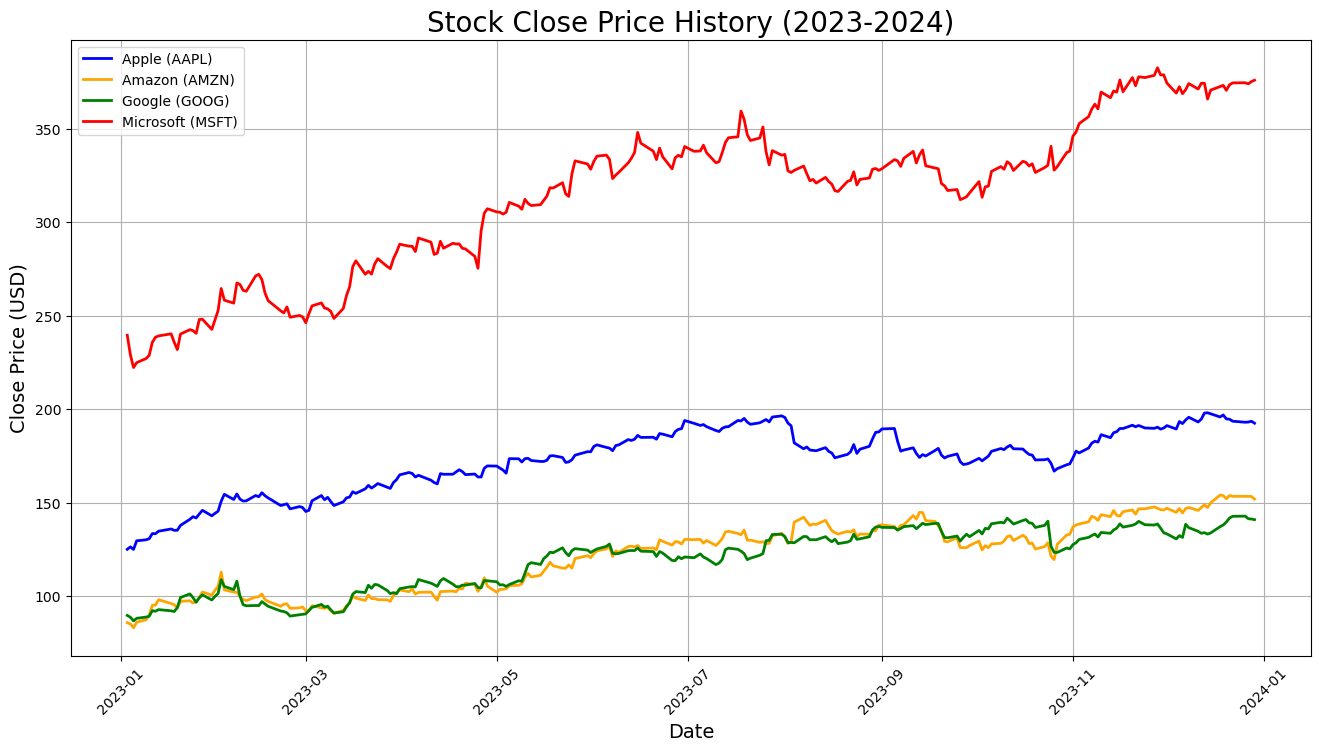

In [5]:


import matplotlib.pyplot as plt
import pandas as pd

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
amzn_data = pd.read_csv('AMZN.csv')
goog_data = pd.read_csv('GOOG.csv')
msft_data = pd.read_csv('MSFT.csv')

# Convert the 'Date' column to datetime format for each dataset
aapl_data['Date'] = pd.to_datetime(aapl_data['Date'])
amzn_data['Date'] = pd.to_datetime(amzn_data['Date'])
goog_data['Date'] = pd.to_datetime(goog_data['Date'])
msft_data['Date'] = pd.to_datetime(msft_data['Date'])

# Filter data to include only dates from 2023-01-01 to 2024-01-01 for each dataset
aapl_filtered = aapl_data[(aapl_data['Date'] >= '2023-01-01') & (aapl_data['Date'] <= '2024-01-01')]
amzn_filtered = amzn_data[(amzn_data['Date'] >= '2023-01-01') & (amzn_data['Date'] <= '2024-01-01')]
goog_filtered = goog_data[(goog_data['Date'] >= '2023-01-01') & (goog_data['Date'] <= '2024-01-01')]
msft_filtered = msft_data[(msft_data['Date'] >= '2023-01-01') & (msft_data['Date'] <= '2024-01-01')]

# Plotting the filtered data for each stock
plt.figure(figsize=(16, 8))

# Apple
plt.plot(aapl_filtered['Date'], aapl_filtered['Close'], label='Apple (AAPL)', color='blue', linewidth=2)
# Amazon
plt.plot(amzn_filtered['Date'], amzn_filtered['Close'], label='Amazon (AMZN)', color='orange', linewidth=2)
# Google
plt.plot(goog_filtered['Date'], goog_filtered['Close'], label='Google (GOOG)', color='green', linewidth=2)
# Microsoft
plt.plot(msft_filtered['Date'], msft_filtered['Close'], label='Microsoft (MSFT)', color='red', linewidth=2)

# Customizing the plot
plt.title('Stock Close Price History (2023-2024)', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price (USD)', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
goog_data = pd.read_csv('GOOG.csv')
amzn_data = pd.read_csv('AMZN.csv')
msft_data = pd.read_csv('MSFT.csv')

# Convert the 'Date' column to datetime and set as index
for data in [aapl_data, goog_data, amzn_data, msft_data]:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Define a function to perform the LSTM prediction for a given dataset
def train_and_predict_lstm(data):
    # Filter data to include only dates from 2023-01-01 to 2024-01-01
    filtered_data = data[(data.index >= '2022-01-01') & (data.index <= '2024-01-01')]
    
    # Create a new dataframe with only the 'Close' column
    close_data = filtered_data.filter(['Close'])

    # Convert the dataframe to a numpy array
    dataset = close_data.values

    # Get the number of rows to train the model on
    training_data_len = int(np.ceil(len(dataset) * 0.95))

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create the training data set
    train_data = scaled_data[0:training_data_len, :]

    # Split the data into x_train and y_train
    x_train = []
    y_train = []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    # Convert to numpy arrays
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    # Create the testing data set
    test_data = scaled_data[training_data_len - 60:, :]

    # Create the x_test and y_test data sets
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    # Convert to numpy arrays
    x_test = np.array(x_test)

    # Reshape the data for LSTM input
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get the model's predicted price values
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    return close_data[:training_data_len], close_data[training_data_len:], predictions

# Apply the function to each company dataset and collect results
train_aapl, valid_aapl, pred_aapl = train_and_predict_lstm(aapl_data)
train_goog, valid_goog, pred_goog = train_and_predict_lstm(goog_data)
train_amzn, valid_amzn, pred_amzn = train_and_predict_lstm(amzn_data)
train_msft, valid_msft, pred_msft = train_and_predict_lstm(msft_data)

# Plot the results for all companies in a single graph
plt.figure(figsize=(16, 12))

# Plot Apple
plt.plot(train_aapl.loc['2023-05-01':].index, train_aapl.loc['2023-05-01':]['Close'], label='Apple Train Data', color='blue')
plt.plot(valid_aapl.loc['2023-05-01':].index, valid_aapl.loc['2023-05-01':]['Close'], label='Apple Validation Data', color='orange')
plt.plot(valid_aapl.loc['2023-05-01':].index, pred_aapl[len(pred_aapl) - len(valid_aapl.loc['2023-05-01':]):], label='Apple Predicted Prices', linestyle='--', color='green')

# Plot Google
plt.plot(train_goog.loc['2023-05-01':].index, train_goog.loc['2023-05-01':]['Close'], label='Google Train Data', color='purple')
plt.plot(valid_goog.loc['2023-05-01':].index, valid_goog.loc['2023-05-01':]['Close'], label='Google Validation Data', color='pink')
plt.plot(valid_goog.loc['2023-05-01':].index, pred_goog[len(pred_goog) - len(valid_goog.loc['2023-05-01':]):], label='Google Predicted Prices', linestyle='--', color='red')

# Plot Amazon
plt.plot(train_amzn.loc['2023-05-01':].index, train_amzn.loc['2023-05-01':]['Close'], label='Amazon Train Data', color='cyan')
plt.plot(valid_amzn.loc['2023-05-01':].index, valid_amzn.loc['2023-05-01':]['Close'], label='Amazon Validation Data', color='magenta')
plt.plot(valid_amzn.loc['2023-05-01':].index, pred_amzn[len(pred_amzn) - len(valid_amzn.loc['2023-05-01':]):], label='Amazon Predicted Prices', linestyle='--', color='yellow')

# Plot Microsoft
plt.plot(train_msft.loc['2023-05-01':].index, train_msft.loc['2023-05-01':]['Close'], label='Microsoft Train Data', color='grey')
plt.plot(valid_msft.loc['2023-05-01':].index, valid_msft.loc['2023-05-01':]['Close'], label='Microsoft Validation Data', color='brown')
plt.plot(valid_msft.loc['2023-05-01':].index, pred_msft[len(pred_msft) - len(valid_msft.loc['2023-05-01':]):], label='Microsoft Predicted Prices', linestyle='--', color='black')

# General settings for the plot
plt.title('Stock Price Prediction Model for Major Tech Companies', fontsize=30)
plt.xlabel('Date', fontsize=30)
plt.ylabel('Close Price USD ($)', fontsize=30)
plt.xticks(rotation=45, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


416/416 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0356
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


416/416 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


320/416 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0190

C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0153
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0160
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0101
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


C:\Users\ken\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


896/896 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0089
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


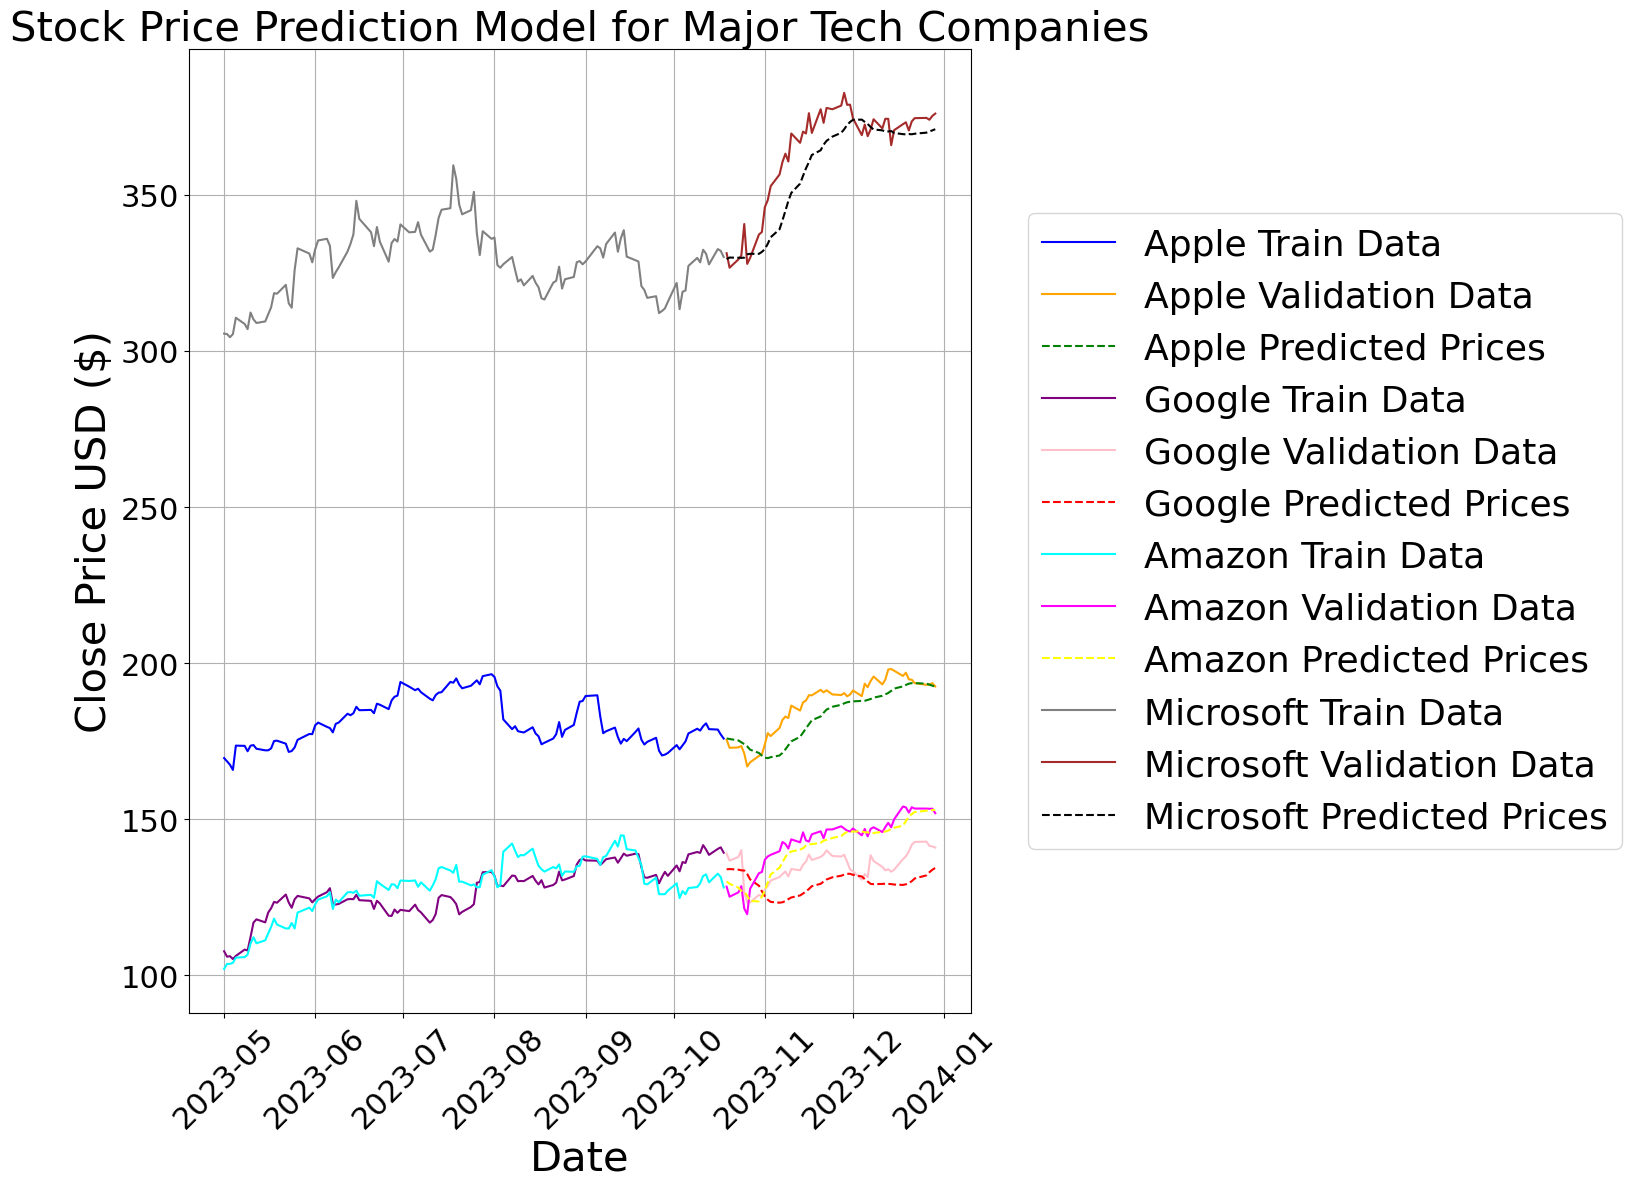

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
goog_data = pd.read_csv('GOOG.csv')
amzn_data = pd.read_csv('AMZN.csv')
msft_data = pd.read_csv('MSFT.csv')

# Convert the 'Date' column to datetime and set as index
for data in [aapl_data, goog_data, amzn_data, msft_data]:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Define a function to perform the LSTM prediction for a given dataset
def train_and_predict_lstm(data):
    # Filter data to include only dates from 2023-01-01 to 2024-01-01
    filtered_data = data[(data.index >= '2020-01-01') & (data.index <= '2024-01-01')]
    
    # Create a new dataframe with only the 'Close' column
    close_data = filtered_data.filter(['Close'])

    # Convert the dataframe to a numpy array
    dataset = close_data.values

    # Get the number of rows to train the model on
    training_data_len = int(np.ceil(len(dataset) * 0.95))

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create the training data set
    train_data = scaled_data[0:training_data_len, :]

    # Split the data into x_train and y_train
    x_train = []
    y_train = []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    # Convert to numpy arrays
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    # Create the testing data set
    test_data = scaled_data[training_data_len - 60:, :]

    # Create the x_test and y_test data sets
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    # Convert to numpy arrays
    x_test = np.array(x_test)

    # Reshape the data for LSTM input
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get the model's predicted price values
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    return close_data[:training_data_len], close_data[training_data_len:], predictions

# Apply the function to each company dataset and collect results
train_aapl, valid_aapl, pred_aapl = train_and_predict_lstm(aapl_data)
train_goog, valid_goog, pred_goog = train_and_predict_lstm(goog_data)
train_amzn, valid_amzn, pred_amzn = train_and_predict_lstm(amzn_data)
train_msft, valid_msft, pred_msft = train_and_predict_lstm(msft_data)

# Plot the results for all companies in a single graph
plt.figure(figsize=(16, 12))

# Plot Apple
plt.plot(train_aapl.loc['2023-05-01':].index, train_aapl.loc['2023-05-01':]['Close'], label='Apple Train Data', color='blue')
plt.plot(valid_aapl.loc['2023-05-01':].index, valid_aapl.loc['2023-05-01':]['Close'], label='Apple Validation Data', color='orange')
plt.plot(valid_aapl.loc['2023-05-01':].index, pred_aapl[len(pred_aapl) - len(valid_aapl.loc['2023-05-01':]):], label='Apple Predicted Prices', linestyle='--', color='green')

# Plot Google
plt.plot(train_goog.loc['2023-05-01':].index, train_goog.loc['2023-05-01':]['Close'], label='Google Train Data', color='purple')
plt.plot(valid_goog.loc['2023-05-01':].index, valid_goog.loc['2023-05-01':]['Close'], label='Google Validation Data', color='pink')
plt.plot(valid_goog.loc['2023-05-01':].index, pred_goog[len(pred_goog) - len(valid_goog.loc['2023-05-01':]):], label='Google Predicted Prices', linestyle='--', color='red')

# Plot Amazon
plt.plot(train_amzn.loc['2023-05-01':].index, train_amzn.loc['2023-05-01':]['Close'], label='Amazon Train Data', color='cyan')
plt.plot(valid_amzn.loc['2023-05-01':].index, valid_amzn.loc['2023-05-01':]['Close'], label='Amazon Validation Data', color='magenta')
plt.plot(valid_amzn.loc['2023-05-01':].index, pred_amzn[len(pred_amzn) - len(valid_amzn.loc['2023-05-01':]):], label='Amazon Predicted Prices', linestyle='--', color='yellow')

# Plot Microsoft
plt.plot(train_msft.loc['2023-05-01':].index, train_msft.loc['2023-05-01':]['Close'], label='Microsoft Train Data', color='grey')
plt.plot(valid_msft.loc['2023-05-01':].index, valid_msft.loc['2023-05-01':]['Close'], label='Microsoft Validation Data', color='brown')
plt.plot(valid_msft.loc['2023-05-01':].index, pred_msft[len(pred_msft) - len(valid_msft.loc['2023-05-01':]):], label='Microsoft Predicted Prices', linestyle='--', color='black')

# General settings for the plot
plt.title('Stock Price Prediction Model for Major Tech Companies', fontsize=30)
plt.xlabel('Date', fontsize=30)
plt.ylabel('Close Price USD ($)', fontsize=30)
plt.xticks(rotation=45, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
goog_data = pd.read_csv('GOOG.csv')
amzn_data = pd.read_csv('AMZN.csv')
msft_data = pd.read_csv('MSFT.csv')

# Convert the 'Date' column to datetime and set as index
for data in [aapl_data, goog_data, amzn_data, msft_data]:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Define a function to perform the RNN prediction for a given dataset
def train_and_predict_rnn(data):
    # Filter data to include only dates from 2023-01-01 to 2024-01-01
    filtered_data = data[(data.index >= '2022-01-01') & (data.index <= '2024-01-01')]
    
    # Create a new dataframe with only the 'Close' column
    close_data = filtered_data.filter(['Close'])

    # Convert the dataframe to a numpy array
    dataset = close_data.values

    # Get the number of rows to train the model on
    training_data_len = int(np.ceil(len(dataset) * 0.95))

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create the training data set
    train_data = scaled_data[0:training_data_len, :]

    # Split the data into x_train and y_train
    x_train = []
    y_train = []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    # Convert to numpy arrays
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data for RNN input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the RNN model
    model = Sequential()
    model.add(SimpleRNN(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(SimpleRNN(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    # Create the testing data set
    test_data = scaled_data[training_data_len - 60:, :]

    # Create the x_test and y_test data sets
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    # Convert to numpy arrays
    x_test = np.array(x_test)

    # Reshape the data for RNN input
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get the model's predicted price values
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    return close_data[:training_data_len], close_data[training_data_len:], predictions

# Apply the function to each company dataset and collect results
train_aapl, valid_aapl, pred_aapl = train_and_predict_rnn(aapl_data)
train_goog, valid_goog, pred_goog = train_and_predict_rnn(goog_data)
train_amzn, valid_amzn, pred_amzn = train_and_predict_rnn(amzn_data)
train_msft, valid_msft, pred_msft = train_and_predict_rnn(msft_data)

# Plot the results for all companies in a single graph
plt.figure(figsize=(16, 12))

# Plot Apple
plt.plot(train_aapl.loc['2023-05-01':].index, train_aapl.loc['2023-05-01':]['Close'], label='Apple Train Data', color='blue')
plt.plot(valid_aapl.loc['2023-05-01':].index, valid_aapl.loc['2023-05-01':]['Close'], label='Apple Validation Data', color='orange')
plt.plot(valid_aapl.loc['2023-05-01':].index, pred_aapl[len(pred_aapl) - len(valid_aapl.loc['2023-05-01':]):], label='Apple Predicted Prices', linestyle='--', color='green')

# Plot Google
plt.plot(train_goog.loc['2023-05-01':].index, train_goog.loc['2023-05-01':]['Close'], label='Google Train Data', color='purple')
plt.plot(valid_goog.loc['2023-05-01':].index, valid_goog.loc['2023-05-01':]['Close'], label='Google Validation Data', color='pink')
plt.plot(valid_goog.loc['2023-05-01':].index, pred_goog[len(pred_goog) - len(valid_goog.loc['2023-05-01':]):], label='Google Predicted Prices', linestyle='--', color='red')

# Plot Amazon
plt.plot(train_amzn.loc['2023-05-01':].index, train_amzn.loc['2023-05-01':]['Close'], label='Amazon Train Data', color='cyan')
plt.plot(valid_amzn.loc['2023-05-01':].index, valid_amzn.loc['2023-05-01':]['Close'], label='Amazon Validation Data', color='magenta')
plt.plot(valid_amzn.loc['2023-05-01':].index, pred_amzn[len(pred_amzn) - len(valid_amzn.loc['2023-05-01':]):], label='Amazon Predicted Prices', linestyle='--', color='yellow')

# Plot Microsoft
plt.plot(train_msft.loc['2023-05-01':].index, train_msft.loc['2023-05-01':]['Close'], label='Microsoft Train Data', color='grey')
plt.plot(valid_msft.loc['2023-05-01':].index, valid_msft.loc['2023-05-01':]['Close'], label='Microsoft Validation Data', color='brown')
plt.plot(valid_msft.loc['2023-05-01':].index, pred_msft[len(pred_msft) - len(valid_msft.loc['2023-05-01':]):], label='Microsoft Predicted Prices', linestyle='--', color='black')

# General settings for the plot
plt.title('Stock Price Prediction Model for Major Tech Companies (RNN)', fontsize=30)
plt.xlabel('Date', fontsize=30)
plt.ylabel('Close Price USD ($)', fontsize=30)
plt.xticks(rotation=45, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error

# Modify the train_and_predict_lstm function to return RMSE
def train_and_predict_lstm_with_rmse(data):
    # Your existing code ...
    filtered_data = data[(data.index >= '2020-01-01') & (data.index <= '2024-01-01')]
    close_data = filtered_data.filter(['Close'])
    dataset = close_data.values
    training_data_len = int(np.ceil(len(dataset) * 0.95))
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)
    train_data = scaled_data[0:training_data_len, :]
    
    x_train, y_train = [], []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    test_data = scaled_data[training_data_len - 60:, :]
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    return close_data[:training_data_len], close_data[training_data_len:], predictions, rmse

# Use the modified function and collect RMSE for each dataset
train_aapl, valid_aapl, pred_aapl, rmse_aapl = train_and_predict_lstm_with_rmse(aapl_data)
train_goog, valid_goog, pred_goog, rmse_goog = train_and_predict_lstm_with_rmse(goog_data)
train_amzn, valid_amzn, pred_amzn, rmse_amzn = train_and_predict_lstm_with_rmse(amzn_data)
train_msft, valid_msft, pred_msft, rmse_msft = train_and_predict_lstm_with_rmse(msft_data)

# Print RMSE values
print(f"Apple RMSE: {rmse_aapl}")
print(f"Google RMSE: {rmse_goog}")
print(f"Amazon RMSE: {rmse_amzn}")
print(f"Microsoft RMSE: {rmse_msft}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

# Load each CSV file using pandas
aapl_data = pd.read_csv('AAPL.csv')
goog_data = pd.read_csv('GOOG.csv')
amzn_data = pd.read_csv('AMZN.csv')
msft_data = pd.read_csv('MSFT.csv')

# Convert the 'Date' column to datetime and set as index
for data in [aapl_data, goog_data, amzn_data, msft_data]:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Define a function to perform the RNN prediction for a given dataset
def train_and_predict_rnn(data):
    # Filter data to include only dates from 2023-01-01 to 2024-01-01
    filtered_data = data[(data.index >= '2020-01-01') & (data.index <= '2024-01-01')]
    
    # Create a new dataframe with only the 'Close' column
    close_data = filtered_data.filter(['Close'])

    # Convert the dataframe to a numpy array
    dataset = close_data.values

    # Get the number of rows to train the model on
    training_data_len = int(np.ceil(len(dataset) * 0.95))

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create the training data set
    train_data = scaled_data[0:training_data_len, :]

    # Split the data into x_train and y_train
    x_train = []
    y_train = []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    # Convert to numpy arrays
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data for RNN input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the RNN model
    model = Sequential()
    model.add(SimpleRNN(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(SimpleRNN(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    # Create the testing data set
    test_data = scaled_data[training_data_len - 60:, :]

    # Create the x_test and y_test data sets
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    # Convert to numpy arrays
    x_test = np.array(x_test)

    # Reshape the data for RNN input
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get the model's predicted price values
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    return close_data[:training_data_len], close_data[training_data_len:], predictions

# Apply the function to each company dataset and collect results
train_aapl, valid_aapl, pred_aapl = train_and_predict_rnn(aapl_data)
train_goog, valid_goog, pred_goog = train_and_predict_rnn(goog_data)
train_amzn, valid_amzn, pred_amzn = train_and_predict_rnn(amzn_data)
train_msft, valid_msft, pred_msft = train_and_predict_rnn(msft_data)

# Plot the results for all companies in a single graph
plt.figure(figsize=(16, 12))

# Plot Apple
plt.plot(train_aapl.loc['2023-05-01':].index, train_aapl.loc['2023-05-01':]['Close'], label='Apple Train Data', color='blue')
plt.plot(valid_aapl.loc['2023-05-01':].index, valid_aapl.loc['2023-05-01':]['Close'], label='Apple Validation Data', color='orange')
plt.plot(valid_aapl.loc['2023-05-01':].index, pred_aapl[len(pred_aapl) - len(valid_aapl.loc['2023-05-01':]):], label='Apple Predicted Prices', linestyle='--', color='green')

# Plot Google
plt.plot(train_goog.loc['2023-05-01':].index, train_goog.loc['2023-05-01':]['Close'], label='Google Train Data', color='purple')
plt.plot(valid_goog.loc['2023-05-01':].index, valid_goog.loc['2023-05-01':]['Close'], label='Google Validation Data', color='pink')
plt.plot(valid_goog.loc['2023-05-01':].index, pred_goog[len(pred_goog) - len(valid_goog.loc['2023-05-01':]):], label='Google Predicted Prices', linestyle='--', color='red')

# Plot Amazon
plt.plot(train_amzn.loc['2023-05-01':].index, train_amzn.loc['2023-05-01':]['Close'], label='Amazon Train Data', color='cyan')
plt.plot(valid_amzn.loc['2023-05-01':].index, valid_amzn.loc['2023-05-01':]['Close'], label='Amazon Validation Data', color='magenta')
plt.plot(valid_amzn.loc['2023-05-01':].index, pred_amzn[len(pred_amzn) - len(valid_amzn.loc['2023-05-01':]):], label='Amazon Predicted Prices', linestyle='--', color='yellow')

# Plot Microsoft
plt.plot(train_msft.loc['2023-05-01':].index, train_msft.loc['2023-05-01':]['Close'], label='Microsoft Train Data', color='grey')
plt.plot(valid_msft.loc['2023-05-01':].index, valid_msft.loc['2023-05-01':]['Close'], label='Microsoft Validation Data', color='brown')
plt.plot(valid_msft.loc['2023-05-01':].index, pred_msft[len(pred_msft) - len(valid_msft.loc['2023-05-01':]):], label='Microsoft Predicted Prices', linestyle='--', color='black')

# General settings for the plot
plt.title('Stock Price Prediction Model for Major Tech Companies (RNN)', fontsize=30)
plt.xlabel('Date', fontsize=30)
plt.ylabel('Close Price USD ($)', fontsize=30)
plt.xticks(rotation=45, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()
